# Coupled trajectories in a sinusoidal + harmonic trap


## Cell below is just for aesthetics. You can markdown it or delete it completely.

In [1]:
import seaborn as sns
from cycler import cycler

main_colours = ["#4C6A92", "#b83737", "#D0AA4A", "#4AA3D0"]
edge_colour = "#131313"

custom_params = {
    "xtick.direction": "in",
    "ytick.direction": "in",
    "lines.markeredgecolor": edge_colour,
    "lines.markeredgewidth": 1.25,
    "figure.dpi": 200,
    "text.usetex": True,
    "font.family": "serif",
    "axes.prop_cycle": cycler(color=main_colours),
}

sns.set_theme(context="talk", style="ticks", rc=custom_params)

In [2]:
#   pip install cython, setuptools
%load_ext Cython

In [3]:
%%cython
# cython: boundscheck=False, wraparound=False, cdivision=True, nonecheck=False, language_level=3

import cython
import numpy as np
cimport numpy as np
from scipy.interpolate import interp1d
from libc.math cimport cos, sin, exp
from scipy.integrate import trapezoid

ctypedef np.float64_t dtype_t


cdef dtype_t phi_prime_1(dtype_t q, dtype_t alpha, dtype_t l, dtype_t pi):
    # Potential derivative for phi_1(q) = alpha sin(2 pi q/l)
    return 2.0 * pi * alpha / l * cos(2.0 * pi * q / l)


cdef dtype_t phi_prime_2(dtype_t q, dtype_t kappa):
    # Potential derivative for phi_2(q) = q^2/(2 kappa)
    return q / kappa


cdef dtype_t phi_1(dtype_t q, dtype_t alpha, dtype_t l, dtype_t pi):
    return alpha * sin(2.0 * pi * q / l)


cdef dtype_t phi_2(dtype_t q, dtype_t kappa):
    return q * q / (2.0 * kappa)


def _Peq_projection1D_q1(double q1, double alpha, double l, double pi):
    return exp(-phi_1(q1, alpha, l, pi))


def _Peq_projection1D_q2(double q2, double kappa):
    return exp(-phi_2(q2, kappa))


def Peq_projection1D_q1(q1, double alpha, double l, double pi):
    P = np.array([_Peq_projection1D_q1(float(q1i), alpha, l, pi) for q1i in q1], dtype=np.float64)
    return P / trapezoid(P, q1)


def Peq_projection1D_q2(q2, double kappa):
    P = np.array([_Peq_projection1D_q2(float(q2i), kappa) for q2i in q2], dtype=np.float64)
    return P / trapezoid(P, q2)


def sample_sin(q_sample, Peq_projection1D_q, double alpha, double l, double pi):
    y_q = Peq_projection1D_q1(q_sample, alpha, l, pi)
    cdf_y_q = np.cumsum(y_q)
    cdf_y_q = cdf_y_q / cdf_y_q.max()

    # Ensure the interpolation domain includes exactly 0 and 1.
    cdf_y_q[0] = 0.0
    cdf_y_q[-1] = 1.0
    return interp1d(cdf_y_q, q_sample, bounds_error=False, fill_value=(q_sample[0], q_sample[-1]))


def sample_optic(q_sample, Peq_projection1D_q, double kappa):
    y_q = Peq_projection1D_q2(q_sample, kappa)
    cdf_y_q = np.cumsum(y_q)
    cdf_y_q = cdf_y_q / cdf_y_q.max()

    # Ensure the interpolation domain includes exactly 0 and 1.
    cdf_y_q[0] = 0.0
    cdf_y_q[-1] = 1.0
    return interp1d(cdf_y_q, q_sample, bounds_error=False, fill_value=(q_sample[0], q_sample[-1]))


cdef (dtype_t, dtype_t) update_q_values(
    dtype_t q1_current,
    dtype_t q2_current,
    dtype_t phi_prime_1_current,
    dtype_t phi_prime_2_current,
    dtype_t eta_1_current,
    dtype_t eta_2_current,
    dtype_t gamma_11,
    dtype_t gamma_12,
    dtype_t gamma_22,
    dtype_t gamma_ratio_11,
    dtype_t gamma_ratio_22,
    dtype_t tau,
):
    cdef dtype_t q1_next, q2_next

    q1_next = q1_current + (gamma_11 - (gamma_12 * gamma_12 / gamma_22))**(-1.0) * (
        tau * (-phi_prime_1_current + gamma_ratio_22 * phi_prime_2_current)
        + eta_1_current - gamma_ratio_22 * eta_2_current
    )

    q2_next = q2_current + (gamma_22 - (gamma_12 * gamma_12 / gamma_11))**(-1.0) * (
        tau * (-phi_prime_2_current + gamma_ratio_11 * phi_prime_1_current)
        + eta_2_current - gamma_ratio_11 * eta_1_current
    )

    return q1_next, q2_next


cdef qi_full_arrays(
    dtype_t[:] eta_1,
    dtype_t[:] eta_2,
    dtype_t gamma_11,
    dtype_t gamma_12,
    dtype_t gamma_22,
    dtype_t kappa,
    dtype_t alpha,
    dtype_t l,
    int N,
    dtype_t tau,
):
    cdef np.ndarray[dtype_t, ndim=1] q1 = np.zeros(N, dtype=np.float64)
    cdef np.ndarray[dtype_t, ndim=1] q2 = np.zeros(N, dtype=np.float64)
    cdef dtype_t pi = 3.14159265358979323846

    cdef dtype_t gamma_ratio_22 = gamma_12 / gamma_22
    cdef dtype_t gamma_ratio_11 = gamma_12 / gamma_11

    cdef np.ndarray[dtype_t, ndim=1] q1_theo = np.linspace(-l, l, N, dtype=np.float64)
    cdef np.ndarray[dtype_t, ndim=1] q2_theo = np.linspace(-0.1, 0.1, N, dtype=np.float64)

    inverse_cdf_q1 = sample_sin(q1_theo, Peq_projection1D_q1, alpha, l, pi)
    inverse_cdf_q2 = sample_optic(q2_theo, Peq_projection1D_q2, kappa)

    q1[0] = inverse_cdf_q1(np.random.uniform(1e-15, 1.0 - 1e-15))
    q2[0] = inverse_cdf_q2(np.random.uniform(1e-15, 1.0 - 1e-15))

    cdef dtype_t _phi_prime_1
    cdef dtype_t _phi_prime_2
    cdef int i

    for i in range(1, N):
        _phi_prime_1 = phi_prime_1(q1[i - 1], alpha, l, pi)
        _phi_prime_2 = phi_prime_2(q2[i - 1], kappa)

        q1[i], q2[i] = update_q_values(
            q1[i - 1], q2[i - 1],
            _phi_prime_1, _phi_prime_2,
            eta_1[i - 1], eta_2[i - 1],
            gamma_11, gamma_12, gamma_22,
            gamma_ratio_11, gamma_ratio_22,
            tau,
        )

    return np.asarray(q1), np.asarray(q2)


def friction_matrix(double g_11, double g_12, double g_22):
    gamma_11 = g_11**2 + g_12**2
    gamma_12 = g_12 * (g_11 + g_22)
    gamma_22 = g_22**2 + g_12**2
    return gamma_11, gamma_12, gamma_22

import scipy as sp

def trajectory_sin_trap(int N, double g_11, double g_12, double g_22, double gamma_11, double gamma_12, double gamma_22, double tau, double kappa, double alpha, double l, seed=None):
    if seed is not None:
        np.random.seed(seed)

    # cdef dtype_t gamma_11, gamma_12, gamma_22
    # gamma_11, gamma_12, gamma_22 = friction_matrix(g_11, g_12, g_22)

    cdef np.ndarray[dtype_t, ndim=1] xi_1 = np.sqrt(2.0) * np.random.normal(0.0, np.sqrt(tau), N).astype(np.float64)
    cdef np.ndarray[dtype_t, ndim=1] xi_2 = np.sqrt(2.0) * np.random.normal(0.0, np.sqrt(tau), N).astype(np.float64)

    cdef np.ndarray[dtype_t, ndim=1] eta_1 = (g_11 * xi_1 + g_12 * xi_2).astype(np.float64)
    cdef np.ndarray[dtype_t, ndim=1] eta_2 = (g_12 * xi_1 + g_22 * xi_2).astype(np.float64)

    return qi_full_arrays(eta_1, eta_2, gamma_11, gamma_12, gamma_22, kappa, alpha, l, N, tau)

Now for the no-coupling case. We have a lot of shananigans to do due to matrix calculus.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

# --------------------
# Parameters to edit
# --------------------
# Please state who you are or the code will crash in your hands. You can only be a me or a notme.
identity = "me"  # "notme"


N = 100_000_000  # number of timesteps to simulate. Do more for better stats.
seed = 120458445  # Change the seed to play around with different trajectories.

tau = 5e-5  # timestep
alpha = 2.7  # sinusoidal potential amplitude
l = 0.5  # sinusoidal period scale
kappa = 0.1  # harmonic trap compliance parameter for q2

gamma_11 = 1.0
gamma_12 = 0.8
gamma_22 = 1.0
Gamma = np.array([[gamma_11, gamma_12], [gamma_12, gamma_22]])
Mu = sp.linalg.inv(Gamma)
############ DONT TOUCH THE REST ###############


gamma_11 = Gamma[0, 0]
gamma_12 = Gamma[0, 1]
gamma_22 = Gamma[1, 1]
g = sp.linalg.sqrtm(Gamma)
g_11 = g[0, 0]
g_12 = g[0, 1]
g_22 = g[1, 1]


all_params = {
    "N": N,
    "tau": tau,
    "alpha": alpha,
    "l": l,
    "kappa": kappa,
    "g_11": g_11,
    "g_12": g_12,
    "g_22": g_22,
    "mu_11": Mu[0, 0],
    "mu_12": Mu[0, 1],
    "mu_22": Mu[1, 1],
}

q1, q2 = trajectory_sin_trap(
    N,
    g_11,
    g_12,
    g_22,
    gamma_11,
    gamma_12,
    gamma_22,
    tau,
    kappa,
    alpha,
    l,
    seed=seed,
)

t = np.arange(N) * tau

print(f"q1 shape: {q1.shape}, q2 shape: {q2.shape}")

q1 shape: (100000000,), q2 shape: (100000000,)


Should take about 20 seconds if your computer is not a LG connected fridge. I haven't benchmark'd those.

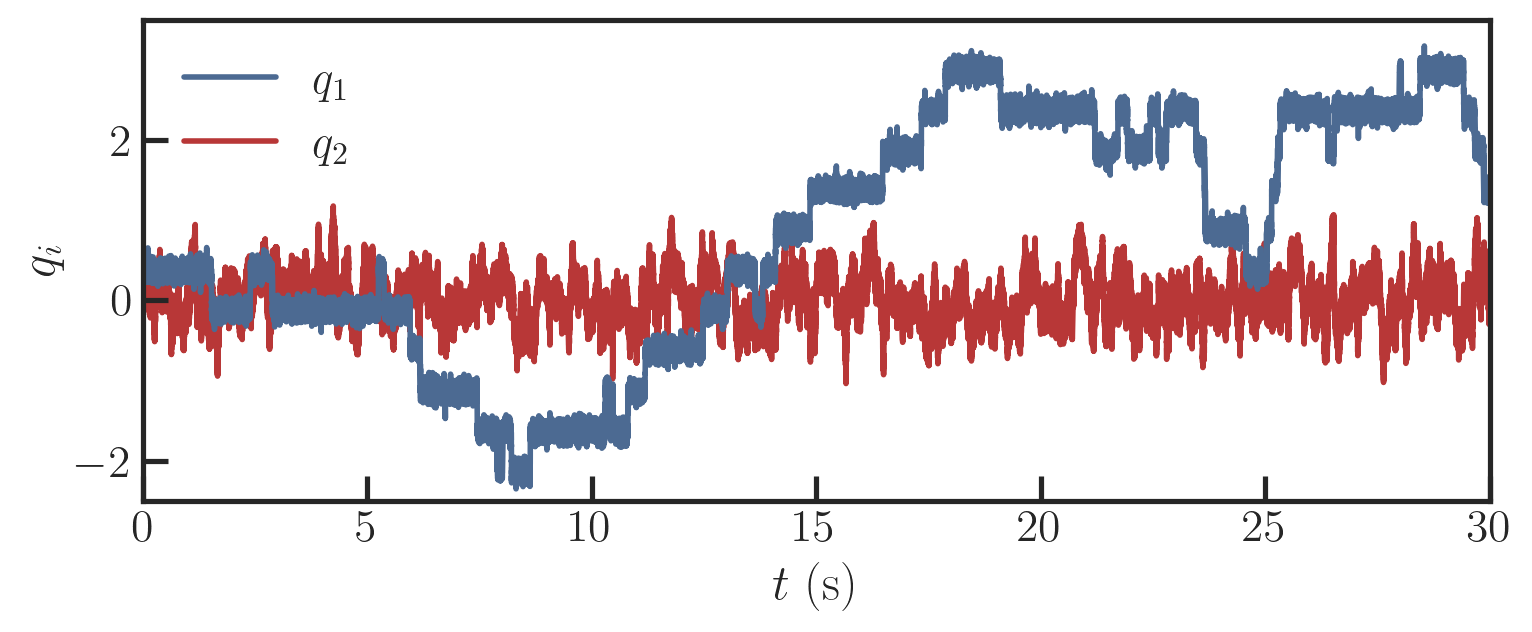

In [57]:
fig, ax = plt.subplots(figsize=(8, 3.5))
lim_low_q1 = -5 * l
lim_high_q1 = 7 * l
lim_low_q2 = -0.15
lim_high_q2 = 0.15
lim_time = 30

ax.set_xlim(0, lim_time)
ax.set_ylim(lim_low_q1, lim_high_q1)
ax.plot(t, q1, label=r"$q_1$", linewidth=2, zorder=0)
ax.plot(t, q2, label=r"$q_2$", linewidth=2, zorder=-1)
ax.set_xlabel(r"$t$ (s)")
ax.set_ylabel(r"$q_i$")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()


if identity == "me":
    plt.savefig(
        "/Users/juls/Desktop/thesis/figures/chapter3/Trajectories.pdf", transparent=True
    )

plt.show()

In [6]:
all_params

{'N': 100000000,
 'tau': 5e-05,
 'alpha': 2.7,
 'l': 0.5,
 'kappa': 0.1,
 'g_11': np.float64(0.8944271909999156),
 'g_12': np.float64(0.4472135954999581),
 'g_22': np.float64(0.8944271909999159),
 'mu_11': np.float64(2.7777777777777786),
 'mu_12': np.float64(-2.222222222222223),
 'mu_22': np.float64(2.7777777777777786)}

# Here is a better view.

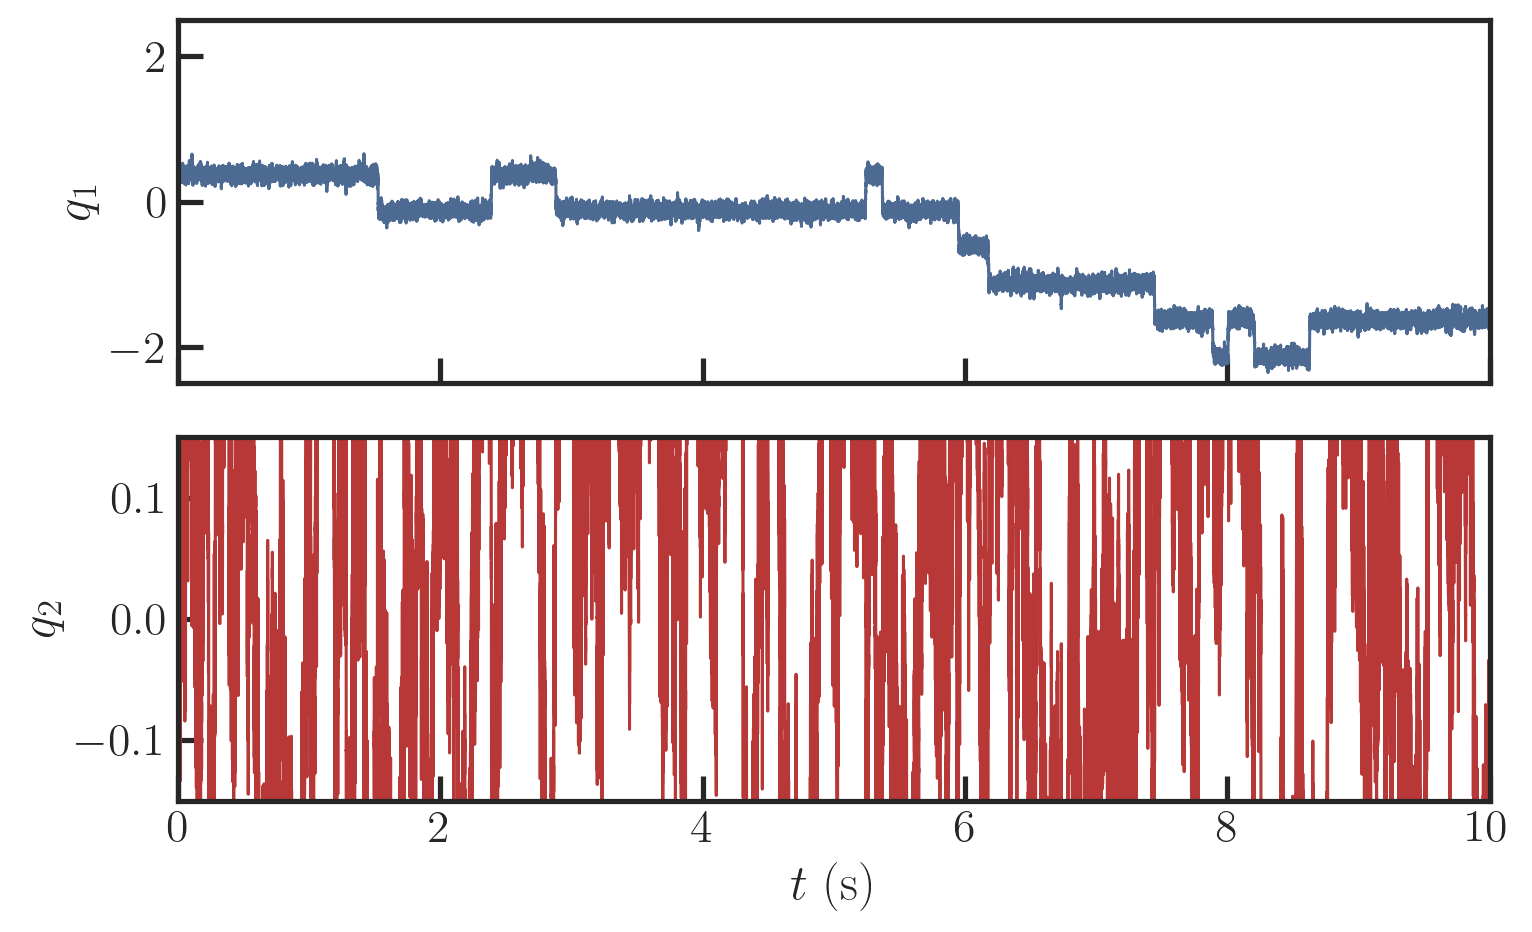

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

lim_low_q1 = -5 * l
lim_high_q1 = 5 * l
lim_low_q2 = -0.15
lim_high_q2 = 0.15
lim_time = 10

axes[0].plot(t, q1, lw=1.1)
axes[0].set_ylabel(r"$q_1$")
axes[0].set_ylim(lim_low_q1, lim_high_q1)
axes[0].set_xlim(0, lim_time)


axes[1].plot(t, q2, lw=1.1, color="C1")
axes[1].set_xlabel(r"$t$ (s)")
axes[1].set_ylabel(r"$q_2$")
axes[1].set_ylim(lim_low_q2, lim_high_q2)
axes[1].set_xlim(0, lim_time)
fig.tight_layout()
plt.show()

# Equilibrium distribution of positions VS histogram of positions should match 1 to 1. 
Sinusoidal modulo $l$ to probe a single period.

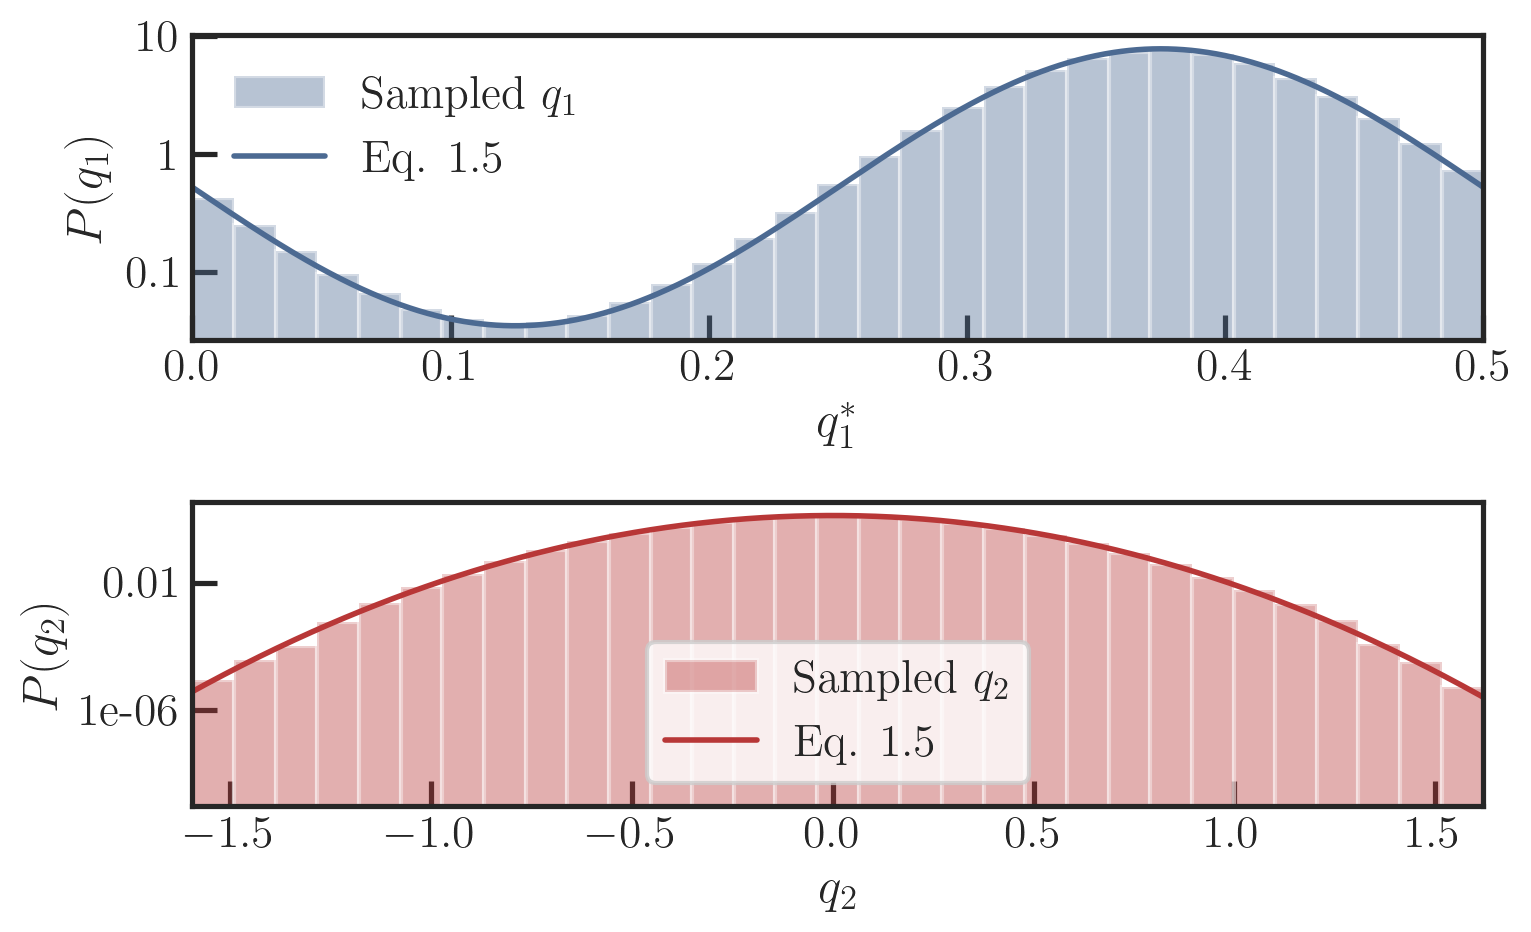

In [58]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from scipy.integrate import trapezoid

pi = np.pi

q1_grid = np.linspace(0, l, 1000)
q2_grid = np.linspace(-2, 2, 1000)

P1 = np.exp(-alpha * np.sin(2 * pi * q1_grid / l))
P1 = P1 / trapezoid(P1, q1_grid)

P2 = np.exp(-(q2_grid**2 / (2 * kappa)))
P2 = P2 / trapezoid(P2, q2_grid)

# ------------------------------------------------------------------
# Two-panel figure
# ------------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(8, 5),
    sharex=False,
)

# ==========================================================
# Top panel : q1
# ==========================================================

ax = axes[0]

ax.hist(
    q1 % l,
    bins=31,
    density=True,
    alpha=0.4,
    label=r"Sampled $q_1$",
    color="C0",
)

ax.plot(
    q1_grid,
    P1,
    lw=2,
    label=r"Eq. 1.5",
    color="C0",
)

ax.set_xlabel(r"$q_1^*$")
ax.set_ylabel(r"$P(q_1)$")
ax.set_xlim(0, l)


ax.set_yscale("log")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:g}"))

ax.yaxis.set_minor_locator(mticker.NullLocator())

ax.legend(frameon=False)

# ==========================================================
# Bottom panel : q2
# ==========================================================

ax = axes[1]

ax.hist(
    q2,
    bins=31,
    density=True,
    alpha=0.4,
    label=r"Sampled $q_2$",
    color="C1",
)

ax.plot(
    q2_grid,
    P2,
    lw=2,
    label=r"Eq. 1.5",
    color="C1",
)

ax.set_xlabel(r"$q_2$")
ax.set_xlim(q2.min(), q2.max())
ax.set_ylabel(r"$P(q_2)$")

ax.set_yscale("log")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:g}"))

ax.yaxis.set_minor_locator(mticker.NullLocator())

ax.legend(frameon=True, loc="lower center")

# ------------------------------------------------------------------

fig.tight_layout()

if identity == "me":
    plt.savefig(
        "/Users/juls/Desktop/thesis/figures/chapter3/Peq_two_panel.pdf",
        transparent=True,
        bbox_inches="tight",
    )

plt.show()

# Simple example of a Mean Squared Displacement plot

You will need more stats to have a satisfactory convergence. Also, I don't compute MSDs this way in the paper, but it's pedagogically more convenient to expose it like this here.

As a reminder, I use the variance of the binned dispplacements to extract the diffusion coefficient, and set a convergence criterion on that distribution to ensure we have reached satisfactory statistics. This means that, in my actual code, the simulations keep running until convergence is reached, and you must remain extra mindful to not ask anything crazy of the code, otherwise you will be stuck there for a while. 

I recommend, for posterior use of the code, that you first estimate on paper what you want, and thoroughly evaluate the necessary computation time to do so.

Also, another important point that I just remembered is that you cannot expect the code to run smoothly without being mindful of how many simulation steps you ask. Because $\tau^*$ is a function of $D^*(\kappa)$, it may become very large for large augmentation factors, while $\tau_2$ remains very small. This, in turn, will generate an unreasonable amount of time steps. 

I have not felt the need to circumvent this, as we have demonstrated the effect for enough parameter ranges that I found my simulations largely sufficient. 

In [10]:
from scipy.special import i0, i1


def MSD(x, lags):
    msd = np.zeros(len(lags))
    for n, lag in enumerate(lags):
        if lag >= len(x):
            msd[n] = np.nan
        else:
            msd[n] = np.nanmean((x[:-lag] - x[lag:]) ** 2)
    return msd


def phi_1(q, alpha, l):
    return alpha * np.sin(2 * np.pi * q / l)


def phi_prime_1(q, alpha, l):
    return 2 * np.pi * alpha / l * np.cos(2 * np.pi * q / l)


def D_rigid_limit(gamma_11, gamma_12, alpha, lambd, kappa):
    """This is David Dean's effecitve long-time diffusion coefficient formula for the rigid limit."""
    q1_th = np.linspace(0, lambd, 1_000_000)
    zpos = trapezoid(np.exp(phi_1(q1_th, alpha, lambd)), q1_th)
    zneg = trapezoid(np.exp(-phi_1(q1_th, alpha, lambd)), q1_th)

    num = 4 * np.pi**2 * gamma_12**2 * alpha * i1(alpha)
    denom = gamma_11**2 * i0(alpha)

    D0 = lambd**2 / (gamma_11 * zpos * zneg)

    return D0 * (1 + kappa / lambd**2 * num / denom)


def D_eff_Lifson_Jackson(gamma_11, alpha, lambd):
    """This is the original, kappa=0 lifson and jackson formula."""
    q1_th = np.linspace(0, lambd, 1_000_000)
    Deff = lambd**2 / (
        trapezoid(np.exp(phi_1(q1_th, alpha, lambd)), q1_th)
        * trapezoid(np.exp(-phi_1(q1_th, alpha, lambd)), q1_th)
        * gamma_11
    )
    return Deff


def D_compliant_limit(lambd, alpha, mu):
    """This is the effective long-time diffusion coefficient formula for the compliant limit."""

    mu_11, mu_12, mu_22 = mu[0, 0], mu[0, 1], mu[1, 1]
    q1_th = np.linspace(0, lambd, 1_000_000)
    zpos = trapezoid(np.exp(phi_1(q1_th, alpha, lambd)), q1_th)
    zneg = trapezoid(np.exp(-phi_1(q1_th, alpha, lambd)), q1_th)
    detmu = mu_11 * mu_22 - mu_12**2

    num = mu_11 * detmu
    denom = lambd ** (-2) * zpos * zneg * detmu + mu_12**2
    return num / denom


lags = np.unique(np.logspace(np.log10(1), np.log10(N // 100), num=50, dtype=int))
print(lags)
msd_q1 = MSD(q1, lags)

msd_q2 = MSD(q2, lags)

[      1       2       3       4       5       7       9      12      16
      22      29      39      51      68      91     120     159     212
     281     372     494     655     868    1151    1526    2023    2682
    3556    4714    6250    8286   10985   14563   19306   25595   33932
   44984   59636   79060  104811  138949  184206  244205  323745  429193
  568986  754312 1000000]


Ya be patient for the msds. Told you it wasn't the best of techniques.

In [ ]:
D_star = D_compliant_limit(l, alpha, Mu)
D_LJ = D_eff_Lifson_Jackson(gamma_11, alpha, l)
tau_star = l**2 / D_star
tau_1 = l**2 / (4 * pi**2 * alpha * Mu[1, 1])
tau_2 = alpha * kappa / Mu[1, 1]
D_m = Mu[0, 0]
D_2 = Mu[1, 1]

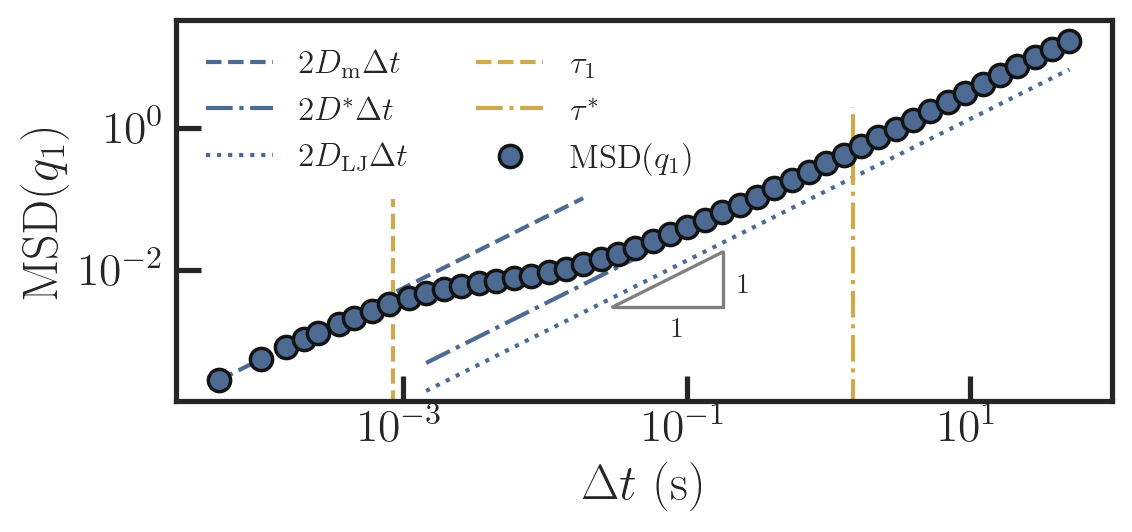

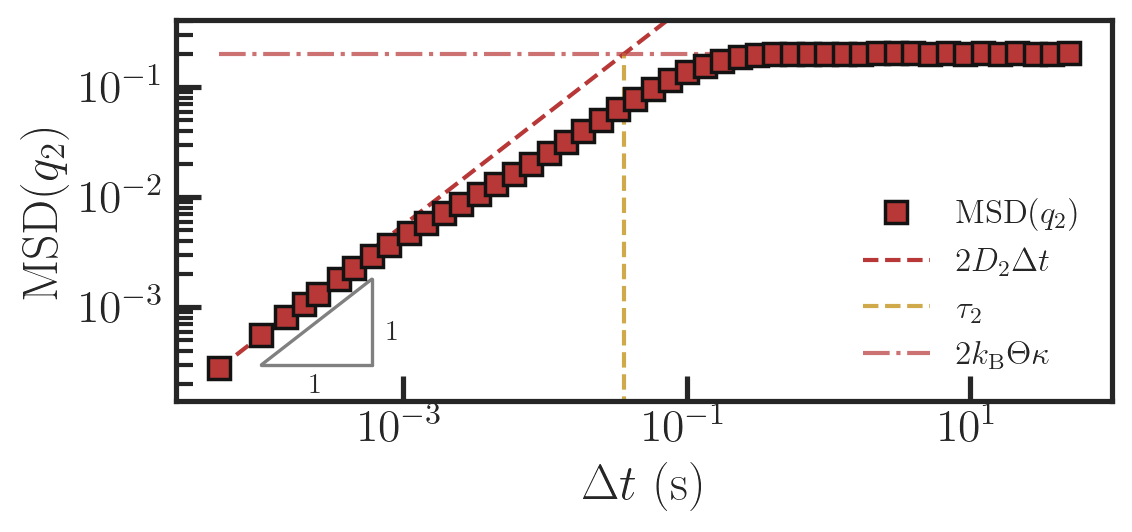

In [70]:
fig, ax = plt.subplots(figsize=(6, 3))

(p_Dm,) = ax.plot(
    lags[:20] * tau,
    2 * D_m * lags[:20] * tau,
    lw=1.5,
    color="C0",
    ls="--",
    label=r"$2 D_\mathrm{m} \Delta t$",
)


(p_Dstar,) = ax.plot(
    lags[10:] * tau,
    2 * D_star * lags[10:] * tau,
    lw=1.5,
    color="C0",
    ls="-.",
    label=r"$2 D^* \Delta t$",
)

(p_DLJ,) = ax.plot(
    lags[10:] * tau,
    2 * D_LJ * lags[10:] * tau,
    lw=1.5,
    color="C0",
    ls=":",
    label=r"$2 D_\mathrm{LJ} \Delta t$",
)

v_tau1 = ax.vlines(
    tau_1,
    ymin=msd_q1.min() * 0.1,
    ymax=1e-1,
    color="C2",
    ls="--",
    lw=1.5,
    label=r"$\tau_1$",
)

v_taustar = ax.vlines(
    tau_star,
    ymin=msd_q1.min() * 0.1,
    ymax=2.0,
    color="C2",
    ls="-.",
    lw=1.5,
    label=r"$\tau^*$",
)

(p_msd,) = ax.plot(
    lags * tau,
    msd_q1,
    lw=2,
    label=r"$\mathrm{MSD}(q_1)$",
    color="C0",
    marker="o",
    markersize=8,
    linestyle="None",
    zorder=10,
)


ax.set_xlabel(r"$\Delta t$ (s)")
ax.set_xlim(0.5 * lags.min() * tau, 2 * lags.max() * tau)
ax.set_ylim(msd_q1.min() / 2, msd_q1.max() * 2)
ax.set_ylabel(r"MSD($q_1$)")

ax.legend(ncols=2, loc="upper left", frameon=False, fontsize=12)

ax.set_xscale("log")
ax.set_yscale("log")


x0 = 3e-2
y0 = 3e-3
dx = 6
slope = 1

x1 = x0 * dx
y1 = y0 * dx**slope

ax.plot([x0, x1], [y0, y0], color="grey", lw=1.2)
ax.plot([x1, x1], [y0, y1], color="grey", lw=1.2)
ax.plot([x0, x1], [y0, y1], color="grey", lw=1.2)

ax.text(
    np.sqrt(x0 * x1) * 1.2,
    y0 / 1.4,
    r"$1$",
    ha="center",
    va="top",
    fontsize=10,
)

ax.text(
    x1 * 1.28,
    np.sqrt(y0 * y1) * 0.8,
    r"$1$",
    ha="left",
    va="center",
    fontsize=10,
)

# leg1 = ax.legend(
#     handles=[p_msd, p_Dm, p_Dstar], loc="upper left", frameon=False, fontsize=9
# )

# leg2 = ax.legend(
#     handles=[p_DLJ, v_tau1, v_taustar], loc="lower right", frameon=False, fontsize=9
# )

# ax.add_artist(leg1)

fig.tight_layout()

if identity == "me":
    plt.savefig(
        "/Users/juls/Desktop/thesis/figures/chapter3/MSD_q1.pdf",
        transparent=True,
        bbox_inches="tight",
    )

plt.show()

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(
    lags * tau,
    msd_q2,
    lw=2,
    label=r"$\mathrm{MSD}(q_2)$",
    color="C1",
    marker="s",
    markersize=8,
    linestyle="None",
    zorder=10,
)

ax.plot(
    lags[:30] * tau,
    2 * D_2 * lags[:30] * tau,
    lw=1.5,
    color="C1",
    ls="--",
    label=r"$2 D_2 \Delta t$",
)
ax.set_xlabel(r"$\Delta t$ (s)")
ax.set_ylabel(r"MSD($q_2$)")
ax.vlines(
    tau_2,
    ymin=msd_q2.min() * 0.1,
    ymax=msd_q2.max(),
    color="C2",
    ls="--",
    lw=1.5,
    label=r"$\tau_2$",
)
ax.hlines(
    2 * kappa,
    xmin=lags.min() * tau,
    xmax=lags.max() * tau,
    color="C1",
    ls="-.",
    lw=1.5,
    label=r"$2 k_\mathrm{B}\Theta\kappa$",
    alpha=0.7,
)

x0 = 1e-4
y0 = 3e-4
dx = 6
slope = 1

x1 = x0 * dx
y1 = y0 * dx**slope

ax.plot([x0, x1], [y0, y0], color="grey", lw=1.2)
ax.plot([x1, x1], [y0, y1], color="grey", lw=1.2)
ax.plot([x0, x1], [y0, y1], color="grey", lw=1.2)

ax.text(
    np.sqrt(x0 * x1),
    y0 / 1.2,
    r"$1$",
    ha="center",
    va="top",
    fontsize=10,
)

ax.text(
    x1 * 1.28,
    np.sqrt(y0 * y1) * 0.8,
    r"$1$",
    ha="left",
    va="center",
    fontsize=10,
)
ax.legend(frameon=False, fontsize=12, loc="lower right")
ax.set_xlim(0.5 * lags.min() * tau, 2 * lags.max() * tau)
ax.set_ylim(msd_q2.min() / 2, msd_q2.max() * 2)
ax.set_xscale("log")
ax.set_yscale("log")
fig.tight_layout()

if identity == "me":
    plt.savefig(
        "/Users/juls/Desktop/thesis/figures/chapter3/MSD_q2.pdf", transparent=True
    )
plt.show()

In [13]:
all_params

{'N': 100000000,
 'tau': 5e-05,
 'alpha': 2.7,
 'l': 0.5,
 'kappa': 0.1,
 'g_11': np.float64(0.8944271909999156),
 'g_12': np.float64(0.4472135954999581),
 'g_22': np.float64(0.8944271909999159),
 'mu_11': np.float64(2.7777777777777786),
 'mu_12': np.float64(-2.222222222222223),
 'mu_22': np.float64(2.7777777777777786)}

In [14]:
D_summary = {
    "D_m": D_m,
    "D_2": D_2,
    "D_star": D_star,
    "D_LJ": D_LJ,
    "tau_1": tau_1,
    "tau_2": tau_2,
    "tau_star": tau_star,
    "augmentation factor": (D_star - D_LJ) / D_LJ,
}

D_summary

{'D_m': np.float64(2.7777777777777786),
 'D_2': np.float64(2.7777777777777786),
 'D_star': np.float64(0.16798304899392308),
 'D_LJ': np.float64(0.0677585632723298),
 'tau_1': np.float64(0.0008443431970194811),
 'tau_2': np.float64(0.03599999999999999),
 'tau_star': np.float64(1.4882454003382446),
 'augmentation factor': np.float64(1.4791412462330262)}

The rest of my published code fits these MSDs, extracts the effective long-time diffusion coefficient from the fits and plots against kappa. 